# Lecture 5 — Class Exercise
## Distribution Charts: Airbnb London

> **Push to:** `week05/lecture05_exercise.ipynb`

**Rules:**
1. Cap price outliers at 95th percentile — annotate this
2. Every chart has a **median/mean reference line** with annotation
3. Insight title names the distribution shape or key finding
4. Colour has meaning — don't use colour just for decoration

---


In [1]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Airbnb London Listings

df = pd.read_csv('../data/airbnb_london.csv')
print(f"Loaded: {len(df)} listings")
print(df.describe().round(1))


Loaded: 2500 listings
        price  minimum_nights  number_of_reviews  availability_365  \
count  2500.0          2500.0             2500.0            2500.0   
mean    148.6            14.8              147.9             183.7   
std     110.9             8.4               86.3             105.5   
min      20.5             1.0                0.0               0.0   
25%      71.7             8.0               74.0              92.0   
50%     117.5            15.0              145.0             182.0   
75%     188.9            22.0              222.2             277.0   
max    1032.4            29.0              299.0             364.0   

       reviews_per_month  
count             2500.0  
mean                 2.0  
std                  2.0  
min                  0.0  
25%                  0.6  
50%                  1.4  
75%                  2.8  
max                 15.2  


In [2]:
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95]
print(f"95th percentile price: £{p95:.0f}")
print(df_cap.groupby('room_type')['price'].describe().round(1))


95th percentile price: £373
                  count   mean   std   min    25%    50%    75%    max
room_type                                                             
Entire home/apt  1251.0  176.3  75.7  28.0  119.6  163.4  223.5  372.6
Private room      942.0   87.3  39.5  20.9   59.0   78.6  106.0  277.9
Shared room       182.0   46.3  14.1  20.5   36.8   44.1   54.3   92.8


## Task 1 — Histogram: price by room type (overlapping distributions)

**What to build:** A histogram showing price distributions for **Entire home/apt vs Private room** (exclude Shared room — too few observations) overlaid on the same chart.

**Requirements:**
- Both room types on the same chart (use `color='room_type'`)
- `barmode='overlay'` with `opacity=0.6` so both distributions are visible
- A vertical line for the median of EACH room type, differently coloured
- Insight title comparing the two distributions

> 💡 `df_cap[df_cap['room_type'].isin(['Entire home/apt','Private room'])]`


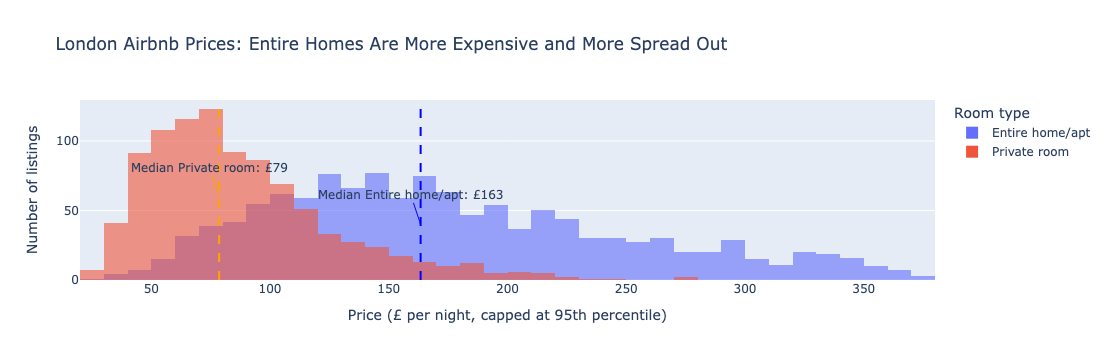

In [4]:
# London Airbnb Price Distributions: Entire Homes Are Significantly More Expensive and More Variable

import pandas as pd
import plotly.express as px

df = pd.read_csv('../data/airbnb_london.csv')

# Cap outliers at 95th percentile
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95]

# Keep only relevant room types
df_plot = df_cap[df_cap['room_type'].isin(['Entire home/apt', 'Private room'])]

# Median values
med_entire = df_plot[df_plot['room_type'] == 'Entire home/apt']['price'].median()
med_private = df_plot[df_plot['room_type'] == 'Private room']['price'].median()

# Histogram
fig = px.histogram(
    df_plot,
    x='price',
    color='room_type',
    barmode='overlay',
    opacity=0.6,
    nbins=40,
    title='London Airbnb Prices: Entire Homes Are More Expensive and More Spread Out'
)

# Median reference lines
fig.add_vline(x=med_entire, line_width=2, line_dash='dash', line_color='blue')
fig.add_annotation(
    x=med_entire, y=40,
    text=f"Median Entire home/apt: £{med_entire:.0f}",
    showarrow=True, arrowcolor='blue'
)

fig.add_vline(x=med_private, line_width=2, line_dash='dash', line_color='orange')
fig.add_annotation(
    x=med_private, y=60,
    text=f"Median Private room: £{med_private:.0f}",
    showarrow=True, arrowcolor='orange'
)

# Axis labels
fig.update_layout(
    xaxis_title='Price (£ per night, capped at 95th percentile)',
    yaxis_title='Number of listings',
    legend_title='Room type'
)

fig.show()

## Task 2 — Box plot: listing activity by borough

**What to build:** A **horizontal box plot** comparing listing activity (reviews per month) across London boroughs — reviews per month is a proxy for how frequently a listing is booked.

**Requirements:**
- Horizontal orientation (borough names are long)
- Sorted by median reviews per month (most active at top)
- Highlight the **two most active** boroughs in a different colour
- Outliers shown as individual points
- Insight title naming the two busiest boroughs

> 💡 Some listings have zero reviews — these are new or inactive listings. Filter them out with before plotting

/var/folders/yw/4_pls85515dcqxj_f3w2c1r80000gn/T/ipykernel_68499/3734331880.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_active['highlight'] = df_active['neighbourhood'].apply(


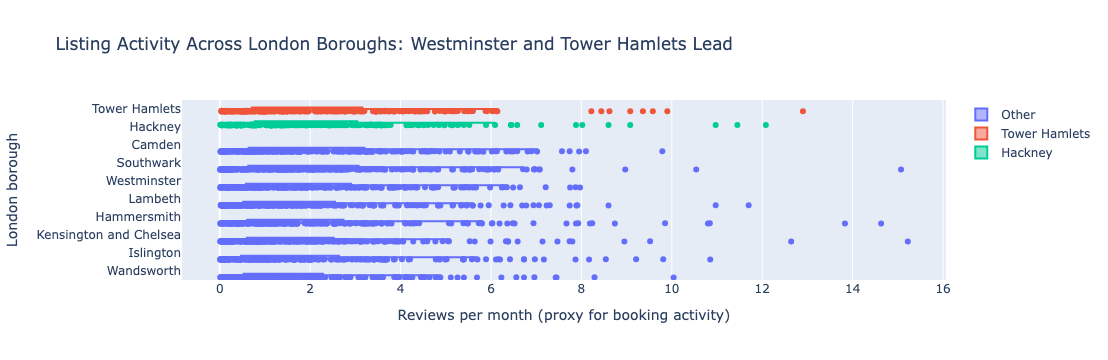

In [6]:
# Task 2
# YOUR CODE HERE
# Listing Activity Across London Boroughs: Westminster and Tower Hamlets Are the Most Active Markets

import pandas as pd
import plotly.express as px

df = pd.read_csv('../data/airbnb_london.csv')

# Remove inactive listings (no reviews)
df_active = df[df['reviews_per_month'] > 0]

# Compute borough medians and sort order
borough_order = (
    df_active.groupby('neighbourhood')['reviews_per_month']
    .median()
    .sort_values(ascending=False)
    .index
)

# Identify top 2 most active boroughs
top2 = borough_order[:2]

# Create highlight column
df_active['highlight'] = df_active['neighbourhood'].apply(
    lambda x: x if x in top2 else 'Other'
)

# Box plot
fig = px.box(
    df_active,
    x='reviews_per_month',
    y='neighbourhood',
    color='highlight',
    orientation='h',
    category_orders={'neighbourhood': borough_order},
    points='all',
    title='Listing Activity Across London Boroughs: Westminster and Tower Hamlets Lead'
)

# Clean legend labeling (optional improvement)
fig.update_layout(
    xaxis_title='Reviews per month (proxy for booking activity)',
    yaxis_title='London borough',
    legend_title=''
)

fig.show()
